In [3]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis import LieTrotter
from qiskit import transpile
from qiskit.circuit.library import PauliEvolutionGate
from pytket import OpType
from pytket.passes import RemoveRedundancies, CommuteThroughMultis, SequencePass, FullPeepholeOptimise, auto_rebase_pass
from pytket.extensions.qiskit import qiskit_to_tk
import matplotlib.pyplot as plt

In [4]:
n_vals = np.arange(2, 14)
k_vals = np.arange(1, 7)
std_binary_gate_counts = np.zeros((len(n_vals), len(k_vals)))
T = 1

for j1, n in enumerate(n_vals):
    N = 2 ** n
    print(f"N={N}")

    pauli_op_list = []
    for i in range(n):
        op = n * ['I']
        op[n-1-i] = 'Z'
        pauli_op_list.append((''.join(op), -2 ** (i)))

    op = n * ['I']
    op[0] = 'Z'
    pauli_op_list.append((''.join(n*['I']), (N - 1)))
    P = SparsePauliOp.from_list(pauli_op_list)

    for j2, k in enumerate(k_vals):
        print(f"k = {k} / {k_vals[-1]}", end="\r")
        pauli_op = ((P / (2 * N)) ** k).simplify()

        circuit = LieTrotter(reps=1).synthesize(PauliEvolutionGate((T * pauli_op).group_commuting()))
        compiled_circuit = transpile(circuit, basis_gates=['rxx', 'rx', 'ry', 'rz'], optimization_level=3)
        ops = compiled_circuit.count_ops()
        num_single_qubit_gates = 0
        num_two_qubit_gates = 0
        for op in ops.keys():
            if op == "rx" or op == "ry" or op == "rz":
                num_single_qubit_gates += ops[op]
            elif op == "rxx":
                num_two_qubit_gates += ops[op]

        # tket_circuit = qiskit_to_tk(compiled_circuit)
        # gateset = {OpType.Rx, OpType.Ry, OpType.Rz, OpType.XXPhase}
        # rebase = auto_rebase_pass(gateset) 
        # comp = SequencePass([FullPeepholeOptimise(), CommuteThroughMultis(), RemoveRedundancies(), rebase])
        # comp.apply(tket_circuit)
        # num_single_qubit_gates, num_two_qubit_gates = tket_circuit.n_1qb_gates(), tket_circuit.n_2qb_gates()

        std_binary_gate_counts[j1, j2] = num_single_qubit_gates + num_two_qubit_gates
    print(f"k = {k} / {k_vals[-1]}")

N=4
k = 6 / 6
N=8
k = 6 / 6
N=16
k = 6 / 6
N=32
k = 6 / 6
N=64
k = 6 / 6
N=128
k = 6 / 6
N=256
k = 6 / 6
N=512
k = 6 / 6
N=1024
k = 6 / 6
N=2048
k = 6 / 6
N=4096
k = 6 / 6
N=8192
k = 6 / 6


In [5]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

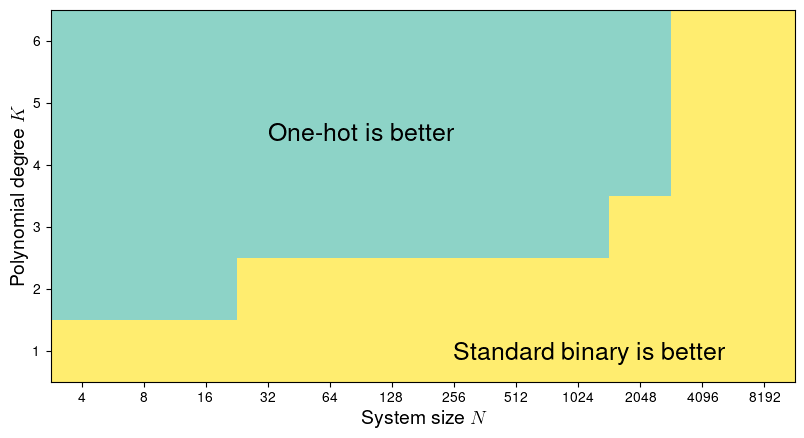

In [7]:
one_hot_gate_counts = np.outer(2 ** n_vals, np.ones(len(k_vals)))

plt.matshow((std_binary_gate_counts < one_hot_gate_counts).T, cmap="Set3")
plt.gca().invert_yaxis()
plt.xlabel(r"System size $N$", fontsize=14)
plt.ylabel(r"Polynomial degree $K$", fontsize=14)
plt.yticks(np.arange(len(k_vals)), k_vals)
plt.xticks(np.arange(len(n_vals)), 2**n_vals)
plt.gca().tick_params(axis="x", labelbottom=True, labeltop=False, top=False)
plt.gca().tick_params(axis="x", labelbottom=True, labeltop=False)
# plt.colorbar()
plt.text(x=6, y=-0.15, s="Standard binary is better", fontsize=18)
plt.text(x=3, y=3.4, s="One-hot is better", fontsize=18)
plt.savefig("../../figures/diagonal_operators.pdf", bbox_inches="tight")
plt.show()